In [1]:

!pip uninstall -y trl peft accelerate transformers tokenizers bitsandbytes
!pip install transformers==4.38.2 peft==0.10.0 accelerate==0.27.2 datasets evaluate rouge_score bert_score scikit-learn scipy

Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1
Found existing installation: accelerate 1.12.0
Uninstalling accelerate-1.12.0:
  Successfully uninstalled accelerate-1.12.0
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.4 MB/s eta 0:00:00
  

In [3]:
from google.colab import files
uploaded = files.upload()

Saving nvdcve-2.0-modified.json.zip to nvdcve-2.0-modified.json (1).zip


In [4]:
import zipfile, os

zip_filename = list(uploaded.keys())[0]
extract_path = "/content/nvd_data"

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)

['nvdcve-2.0-modified.json']

In [5]:
import json

json_file = [f for f in os.listdir(extract_path) if f.endswith(".json")][0]
file_path = os.path.join(extract_path, json_file)

with open(file_path) as f:
    data = json.load(f)

len(data["vulnerabilities"])

3715

In [6]:
processed = []

for item in data["vulnerabilities"]:
    cve_data = item.get("cve", {})
    cve_id = cve_data.get("id")

    description = ""
    for desc in cve_data.get("descriptions", []):
        if desc["lang"] == "en":
            description = desc["value"]
            break

    metrics = cve_data.get("metrics", {})

    cvss_score = None
    attack_vector = "UNKNOWN"

    if "cvssMetricV31" in metrics:
        cvss = metrics["cvssMetricV31"][0]["cvssData"]
        cvss_score = cvss.get("baseScore")
        attack_vector = cvss.get("attackVector")

    elif "cvssMetricV30" in metrics:
        cvss = metrics["cvssMetricV30"][0]["cvssData"]
        cvss_score = cvss.get("baseScore")
        attack_vector = cvss.get("attackVector")

    elif "cvssMetricV2" in metrics:
        cvss = metrics["cvssMetricV2"][0]["cvssData"]
        cvss_score = cvss.get("baseScore")
        attack_vector = cvss.get("accessVector")

    if cvss_score is not None and len(description) > 100:
        processed.append({
            "cve_id": cve_id,
            "description": description,
            "cvss_score": cvss_score,
            "attack_vector": attack_vector
        })

len(processed)

3390

In [7]:
import random
random.seed(42)

dataset = random.sample(processed, 1000)

def assign_risk(score):
    if score >= 9.0:
        return "Critical"
    elif score >= 7.0:
        return "High"
    elif score >= 4.0:
        return "Medium"
    else:
        return "Low"

for item in dataset:
    item["risk_level"] = assign_risk(item["cvss_score"])

In [8]:
def create_output(entry):
    return f"""Executive Summary:
CVE {entry['cve_id']} is a {entry['risk_level']} severity vulnerability with a CVSS score of {entry['cvss_score']}.

Technical Analysis:
{entry['description']}

Business Impact:
Exploitation may compromise confidentiality, integrity, or availability via {entry['attack_vector']} access.

Remediation:
Apply official vendor patches immediately. If unavailable, restrict exposure and disable affected components.

Risk Level:
{entry['risk_level']}"""

for item in dataset:
    item["target_output"] = create_output(item)

In [9]:
from sklearn.model_selection import train_test_split

formatted = []

for item in dataset:
    formatted.append({
        "instruction": "Generate a structured cybersecurity vulnerability summary.",
        "input": f"CVE ID: {item['cve_id']}\nCVSS Score: {item['cvss_score']}\nDescription: {item['description']}",
        "output": item["target_output"]
    })

train_data, temp_data = train_test_split(formatted, test_size=0.3, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

len(train_data), len(val_data), len(test_data)

(700, 150, 150)

##Model Training

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float32   # 🔥 FLOAT32
)

model = model.cuda()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possibl

In [12]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.10229075496156657


In [13]:
from datasets import Dataset

train_dataset = Dataset.from_list(train_data)

def format_prompt(example):
    text = f"""### Instruction:
{example['instruction']}

### Input:
{example['input']}

### Response:
{example['output']}"""
    return {"text": text}

train_dataset = train_dataset.map(format_prompt)

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

In [14]:
def tokenize(example):
    tokens = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=768
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

train_dataset = train_dataset.map(tokenize, batched=True, remove_columns=train_dataset.column_names)
train_dataset.set_format("torch")

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

In [15]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./tinyllama-cyber-ft",
    per_device_train_batch_size=2,   # use 2 for float32
    num_train_epochs=4,
    learning_rate=3e-4,
    fp16=False,                      # 🔥 MUST be False
    logging_steps=50,
    optim="adamw_torch",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

trainer.train()

Step,Training Loss
50,1.690700
100,0.402800
150,0.378700
200,0.401700
250,0.353800
300,0.287200
350,0.357800
400,0.286900
450,0.312800
500,0.357200


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


TrainOutput(global_step=1400, training_loss=0.3608263165610177, metrics={'train_runtime': 3117.9232, 'train_samples_per_second': 0.898, 'train_steps_per_second': 0.449, 'total_flos': 1.33622258466816e+16, 'train_loss': 0.3608263165610177, 'epoch': 4.0})

In [16]:
model.save_pretrained("./tinyllama-cyber-lora")
tokenizer.save_pretrained("./tinyllama-cyber-lora")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


('./tinyllama-cyber-lora/tokenizer_config.json',
 './tinyllama-cyber-lora/special_tokens_map.json',
 './tinyllama-cyber-lora/tokenizer.model',
 './tinyllama-cyber-lora/added_tokens.json',
 './tinyllama-cyber-lora/tokenizer.json')

In [17]:
!zip -r tinyllama-cyber-lora.zip tinyllama-cyber-lora

  adding: tinyllama-cyber-lora/ (stored 0%)
  adding: tinyllama-cyber-lora/adapter_config.json (deflated 51%)
  adding: tinyllama-cyber-lora/README.md (deflated 66%)
  adding: tinyllama-cyber-lora/special_tokens_map.json (deflated 73%)
  adding: tinyllama-cyber-lora/tokenizer.json (deflated 74%)
  adding: tinyllama-cyber-lora/tokenizer.model (deflated 55%)
  adding: tinyllama-cyber-lora/tokenizer_config.json (deflated 69%)
  adding: tinyllama-cyber-lora/adapter_model.safetensors (deflated 8%)


In [18]:
from google.colab import files
files.download("tinyllama-cyber-lora.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Use this when running on different colab notebook instead of training model

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)

base_model = AutoModelForCausalLM.from_pretrained(model_name)

model = PeftModel.from_pretrained(base_model, "path_to_downloaded_lora_folder")

##Continue

In [19]:
def generate_summary(model, tokenizer, instruction, input_text):
    prompt = f"""### Instruction:
{instruction}

### Input:
{input_text}

### Response:
"""
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=300,
        temperature=0.1,
        do_sample=False
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [20]:
ft_predictions = []

for item in test_data:
    output = generate_summary(model, tokenizer, item['instruction'], item['input'])
    response_only = output.split("### Response:")[-1].strip()
    ft_predictions.append(response_only)

len(ft_predictions)

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:410: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


150

In [21]:
from transformers import AutoModelForCausalLM

baseline_model = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    torch_dtype=torch.float32
).cuda()

In [22]:
baseline_predictions = []

for item in test_data:
    output = generate_summary(baseline_model, tokenizer, item['instruction'], item['input'])
    response_only = output.split("### Response:")[-1].strip()
    baseline_predictions.append(response_only)

len(baseline_predictions)

150

##Evaluation

In [26]:
import evaluate

rouge = evaluate.load("rouge")

references = [item["output"] for item in test_data]

ft_scores = rouge.compute(predictions=ft_predictions, references=references)
baseline_scores = rouge.compute(predictions=baseline_predictions, references=references)

print("Fine-Tuned ROUGE:", ft_scores)
print("Baseline ROUGE:", baseline_scores)

Fine-Tuned ROUGE: {'rouge1': np.float64(0.9942442979997035), 'rouge2': np.float64(0.9930563272684712), 'rougeL': np.float64(0.9942287289183344), 'rougeLsum': np.float64(0.9942337471337426)}
Baseline ROUGE: {'rouge1': np.float64(0.5529124431571387), 'rouge2': np.float64(0.4498800343034396), 'rougeL': np.float64(0.49698722432900555), 'rougeLsum': np.float64(0.5276784035417004)}


In [24]:
import re
from sklearn.metrics import classification_report

def extract_risk(text):
    match = re.search(r"Risk Level:\s*(Critical|High|Medium|Low)", text, re.IGNORECASE)
    if match:
        return match.group(1).capitalize()
    return "Unknown"

true_labels = [item["output"].split("Risk Level:")[-1].strip() for item in test_data]
ft_labels = [extract_risk(p) for p in ft_predictions]
baseline_labels = [extract_risk(p) for p in baseline_predictions]

print("Fine-Tuned Classification:")
print(classification_report(true_labels, ft_labels))

print("Baseline Classification:")
print(classification_report(true_labels, baseline_labels))

Fine-Tuned Classification:
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00        18
        High       1.00      0.93      0.97        60
         Low       1.00      0.86      0.92         7
      Medium       1.00      0.92      0.96        65
     Unknown       0.00      0.00      0.00         0

    accuracy                           0.93       150
   macro avg       0.80      0.74      0.77       150
weighted avg       1.00      0.93      0.97       150

Baseline Classification:
              precision    recall  f1-score   support

    Critical       0.00      0.00      0.00      18.0
        High       0.00      0.00      0.00      60.0
         Low       0.00      0.00      0.00       7.0
      Medium       0.00      0.00      0.00      65.0
     Unknown       0.00      0.00      0.00       0.0

    accuracy                           0.00     150.0
   macro avg       0.00      0.00      0.00     150.0
weighted avg       0.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

In [25]:
from scipy.stats import ttest_rel

ft_sample_scores = []
baseline_sample_scores = []

for pred_ft, pred_base, ref in zip(ft_predictions, baseline_predictions, references):
    ft_score = rouge.compute(predictions=[pred_ft], references=[ref])["rougeL"]
    base_score = rouge.compute(predictions=[pred_base], references=[ref])["rougeL"]
    ft_sample_scores.append(ft_score)
    baseline_sample_scores.append(base_score)

t_stat, p_val = ttest_rel(ft_sample_scores, baseline_sample_scores)

print("Mean ROUGE-L (Fine-Tuned):", sum(ft_sample_scores)/len(ft_sample_scores))
print("Mean ROUGE-L (Baseline):", sum(baseline_sample_scores)/len(baseline_sample_scores))
print("T-statistic:", t_stat)
print("P-value:", p_val)

Mean ROUGE-L (Fine-Tuned): 0.9939936315266579
Mean ROUGE-L (Baseline): 0.49769024633978065
T-statistic: 34.1072338821136
P-value: 2.8134957040791224e-72


Graphical Representation

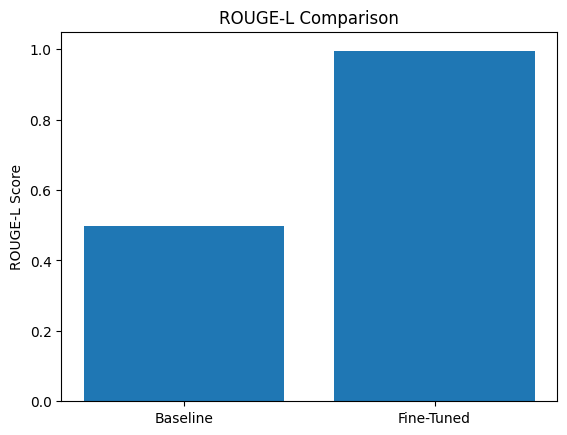

In [27]:
import matplotlib.pyplot as plt

baseline_rougeL = 0.49769024633978065
finetuned_rougeL = 0.9939936315266579

plt.figure()
plt.bar(["Baseline", "Fine-Tuned"], [baseline_rougeL, finetuned_rougeL])
plt.title("ROUGE-L Comparison")
plt.ylabel("ROUGE-L Score")
plt.ylim(0, 1.05)
plt.show()

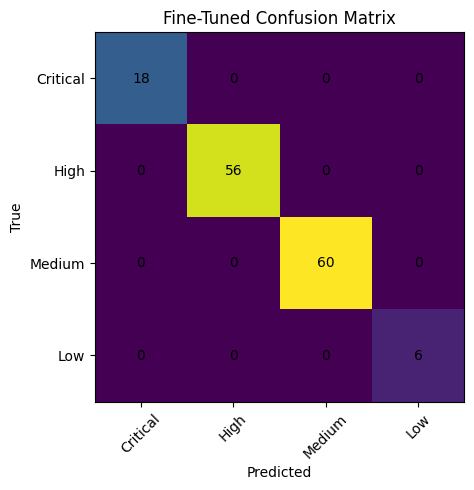

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import re

def extract_risk(text):
    match = re.search(r"Risk Level:\s*(Critical|High|Medium|Low)", text, re.IGNORECASE)
    if match:
        return match.group(1).capitalize()
    return "Unknown"

true_labels = [item["output"].split("Risk Level:")[-1].strip() for item in test_data]
ft_labels = [extract_risk(p) for p in ft_predictions]

labels = ["Critical", "High", "Medium", "Low"]
cm = confusion_matrix(true_labels, ft_labels, labels=labels)

plt.figure()
plt.imshow(cm)
plt.title("Fine-Tuned Confusion Matrix")
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

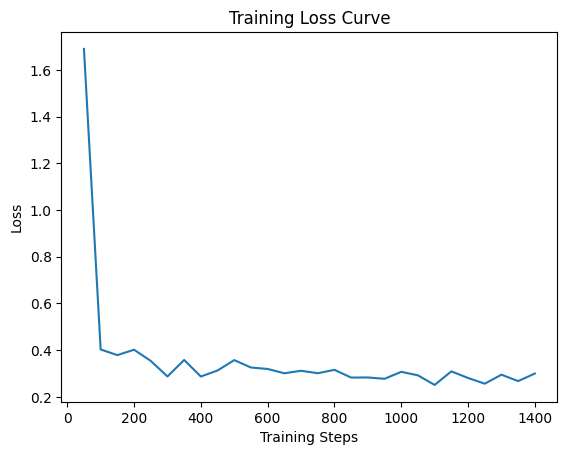

In [29]:
import matplotlib.pyplot as plt

steps = list(range(50, 1401, 50))
loss_values = [
    1.6907, 0.4028, 0.3787, 0.4017, 0.3538, 0.2872, 0.3578,
    0.2869, 0.3128, 0.3572, 0.3255, 0.3193, 0.3008, 0.3116,
    0.3010, 0.3155, 0.2824, 0.2828, 0.2772, 0.3070,
    0.2919, 0.2509, 0.3090, 0.2806, 0.2562, 0.2947,
    0.2673, 0.2997
]

plt.figure()
plt.plot(steps, loss_values)
plt.title("Training Loss Curve")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.show()

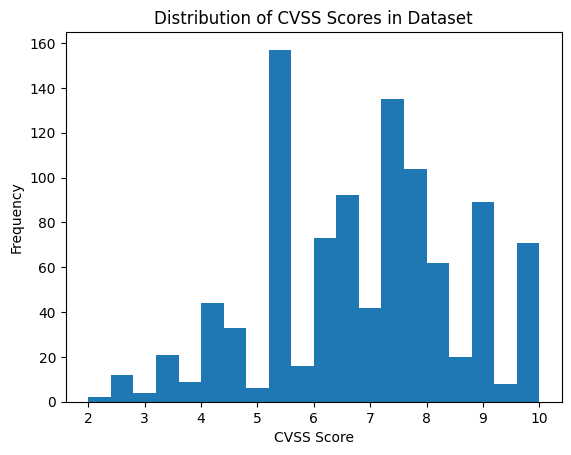

In [30]:
import matplotlib.pyplot as plt

cvss_scores = [item["cvss_score"] for item in dataset]

plt.figure()
plt.hist(cvss_scores, bins=20)
plt.title("Distribution of CVSS Scores in Dataset")
plt.xlabel("CVSS Score")
plt.ylabel("Frequency")
plt.show()